##Kelompok 9
Nama Anggota Kelompok:
1.   Alvi Anggraeni (2211102209)
2.   Rezki Nur Vidhiyansyah (2211102207)



Masalah yang ingin diselesaikan adalah prediksi risiko DBD (Demam Berdarah Dengue) berdasarkan sejumlah fitur kesehatan dan demografis. Fitur yang digunakan antara lain:

*   Umur: Usia pasien.
*   Jumlah Trombosit: Jumlah trombosit dalam darah pasien per mikroliter darah
*   Suhu Tubuh: Suhu tubuh pasien.
*   Ruam Kulit: Adanya ruam pada kulit pasien(ya/tidak)
*   Nyeri Otot: Adanya nyeri otot pada pasien(ya/tidak)
Tujuan dari model ini adalah untuk mengklasifikasikan apakah seorang pasien berisiko terkena DBD berdasarkan data yang tersedia.

1. Import Data dan Library

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
import plotly.express as px

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/data_dbd.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Umur,Jumlah_Trombosit,Suhu_Tubuh,Ruam_Kulit,Nyeri_Otot,Risiko_DBD
0,8,90000,39.5,Ya,Ya,Tinggi
1,15,130000,38.5,Tidak,Ya,Sedang
2,20,80000,40.2,Ya,Ya,Tinggi
3,25,160000,37.5,Tidak,Tidak,Rendah
4,10,110000,39.0,Ya,Ya,Tinggi
...,...,...,...,...,...,...
495,58,183773,36.4,Tidak,Ya,Rendah
496,9,58334,37.2,Ya,Tidak,Tinggi
497,3,322146,36.3,Tidak,Ya,Rendah
498,46,334229,38.4,Tidak,Ya,Sedang


2. EDA (Exploratory Data Analysis)

In [ ]:
# Gambaran umum dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Umur              500 non-null    int64  
 1   Jumlah_Trombosit  500 non-null    int64  
 2   Suhu_Tubuh        500 non-null    float64
 3   Ruam_Kulit        500 non-null    object 
 4   Nyeri_Otot        500 non-null    object 
 5   Risiko_DBD        500 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 23.6+ KB
None
             Umur  Jumlah_Trombosit  Suhu_Tubuh
count  500.000000        500.000000  500.000000
mean    35.556000     251088.906000   38.061800
std     19.955433     113322.432648    1.149767
min      1.000000      50046.000000   36.000000
25%     19.000000     155799.750000   37.100000
50%     34.000000     254224.000000   38.100000
75%     53.000000     348740.750000   39.000000
max     70.000000     449989.000000   40.500000


In [ ]:
# Pastikan tidak ada nilai kosong dan duplikasi
print(df.isnull().sum())
print(f"Duplicated rows: {df.duplicated().sum()}")

Umur                0
Jumlah_Trombosit    0
Suhu_Tubuh          0
Ruam_Kulit          0
Nyeri_Otot          0
Risiko_DBD          0
dtype: int64
Duplicated rows: 0


In [ ]:
# Risiko DBD distribution pie chart
risiko_counts = df['Risiko_DBD'].value_counts().reset_index()
risiko_counts.columns = ['Risiko_DBD', 'Count']
custom_colors = ['#FF5733', '#33FF57', '#3357FF']
fig = px.pie(risiko_counts, names='Risiko_DBD', values='Count',
             title='Distribusi Risiko DBD',
             color='Risiko_DBD',
             color_discrete_map={'Tinggi': custom_colors[0], 'Sedang': custom_colors[1], 'Rendah': custom_colors[2]},
             hole=0.3)
fig.show()

Grafik tersebut adalah diagram donat yang menunjukkan distribusi risiko DBD (Demam Berdarah Dengue).

- **Tinggi** (warna merah): 43%  
- **Sedang** (warna hijau): 39.8%  
- **Rendah** (warna biru): 17.2%

Diagram ini mengindikasikan bahwa risiko tinggi mendominasi, diikuti oleh risiko sedang, sementara risiko rendah merupakan proporsi terkecil.

In [ ]:
# Umur distribution bar chart
bins = [0, 10, 20, 30, 40, 50, 60, 70]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70']
df['Umur_Group'] = pd.cut(df['Umur'], bins=bins, labels=labels, right=True)
umur_counts = df['Umur_Group'].value_counts().sort_index()
custom_colors = ['#FFC300', '#FF5733', '#C70039', '#900C3F', '#581845', '#6C757D', '#28A745']
fig1 = px.bar(umur_counts, x=umur_counts.index, y=umur_counts.values,
              color=umur_counts.index,
              title='Distribusi Umur dalam Dataset',
              color_discrete_map={group: color for group, color in zip(umur_counts.index, custom_colors)})
fig1.update_layout(xaxis_title='Kelompok Umur', yaxis_title='Jumlah Orang', showlegend=False)
fig1.show()

Diagram distribusi umur memberikan representasi visual tentang komposisi umur dalam dataset. Diagram tersebut menunjukkan bahwa jumlah orang dengan umur 21-30 tahun lebih tinggi dibandingkan yang lain.

In [ ]:
# Trombosit distribution bar chart
bins_trombosit = [50000, 100000, 150000, 200000, 250000, 300000]
labels_trombosit = ['50k-100k', '101k-150k', '151k-200k', '201k-250k', '251k-300k']
df['Trombosit_Group'] = pd.cut(df['Jumlah_Trombosit'], bins=bins_trombosit, labels=labels_trombosit, right=True)
trombosit_counts = df['Trombosit_Group'].value_counts().sort_index()
custom_colors_trombosit = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD']
fig2 = px.bar(trombosit_counts, x=trombosit_counts.index, y=trombosit_counts.values,
              color=trombosit_counts.index,
              title='Distribusi Jumlah Trombosit dalam Dataset',
              color_discrete_map={group: color for group, color in zip(trombosit_counts.index, custom_colors_trombosit)})
fig2.update_layout(xaxis_title='Kelompok Jumlah Trombosit', yaxis_title='Jumlah Orang', showlegend=False)
fig2.show()

Diagram distribusi jumlah trombosit memberikan representasi visual tentang komposisi jumlah trombosit dalam dataset. Diagram tersebut menunjukkan bahwa jumlah orang dengan jumlah trombosit 151k-200k lebih tinggi dibandingkan yang lain.

In [ ]:
# Suhu distribution bar chart
bins_suhu = [35, 36, 37, 38, 39, 40]
labels_suhu = ['35-36', '36-37', '37-38', '38-39', '39-40']
df['Suhu_Group'] = pd.cut(df['Suhu_Tubuh'], bins=bins_suhu, labels=labels_suhu, right=True)
suhu_counts = df['Suhu_Group'].value_counts().sort_index()
custom_colors_suhu = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD']
fig3 = px.bar(suhu_counts, x=suhu_counts.index, y=suhu_counts.values,
              color=suhu_counts.index,
              title='Distribusi Suhu Tubuh dalam Dataset (35 hingga 40 Derajat)',
              color_discrete_map={group: color for group, color in zip(suhu_counts.index, custom_colors_suhu)})
fig3.update_layout(xaxis_title='Kelompok Suhu Tubuh (35-40°C)', yaxis_title='Jumlah Orang', showlegend=False)
fig3.show()

Diagram distribusi suhu tubuh memberikan representasi visual tentang komposisi suhu tubuh dalam dataset. Diagram ini menunjukkan bahwa jumlah individu dengan suhu tubuh antara 38-39 derajat lebih tinggi dibandingkan dengan kelompok suhu tubuh lainnya. Sedangkan untuk suhu tubuh antara 37-38 derajat, selisihnya relatif kecil.

In [ ]:
# Hitung jumlah setiap kategori 'Ruam_Kulit'
ruam_counts = df['Ruam_Kulit'].value_counts().reset_index()
ruam_counts.columns = ['Ruam_Kulit', 'Count']

# Pilih warna kustom untuk Ruam Kulit (Ya: 1, Tidak: 0)
custom_colors_ruam = ['#FF6347', '#4682B4']  # Warna untuk Ya dan Tidak

# Buat pie chart untuk Ruam Kulit
fig_ruam = px.pie(ruam_counts,
                  names='Ruam_Kulit',
                  values='Count',
                  title='Distribusi Ruam Kulit',
                  color='Ruam_Kulit',
                  color_discrete_map={
                      1: custom_colors_ruam[0],  # Ya
                      0: custom_colors_ruam[1]   # Tidak
                  },
                  hole=0.3  # Membuat tampilan Donut Chart
                 )

# Tampilkan pie chart Ruam Kulit
fig_ruam.show()

In [ ]:
# Hitung jumlah setiap kategori 'Nyeri_Otot'
nyeri_counts = df['Nyeri_Otot'].value_counts().reset_index()
nyeri_counts.columns = ['Nyeri_Otot', 'Count']

# Pilih warna kustom untuk Nyeri Otot (1: Ya, 0: Tidak)
custom_colors_nyeri = ['#FF5733', '#33FF57']  # Warna untuk Ya dan Tidak

# Buat pie chart untuk Nyeri Otot
fig_nyeri = px.pie(nyeri_counts,
                   names='Nyeri_Otot',
                   values='Count',
                   title='Distribusi Nyeri Otot',
                   color='Nyeri_Otot',
                   color_discrete_map={
                       1: custom_colors_nyeri[0],  # Ya
                       0: custom_colors_nyeri[1]   # Tidak
                   },
                   hole=0.3  # Membuat tampilan Donut Chart
                  )

# Tampilkan pie chart Nyeri Otot
fig_nyeri.show()

In [ ]:
# Kelompokkan umur ke dalam rentang umur
bins = [0, 10, 20, 30, 40, 50, 60, 70]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70']
df['Umur_Group'] = pd.cut(df['Umur'], bins=bins, labels=labels, right=True)

# Hitung jumlah kasus DBD per kelompok umur
umur_dbd_counts = df.groupby(['Umur_Group', 'Risiko_DBD']).size().unstack()

# Hitung persentase risiko DBD "Tinggi" berdasarkan jumlah total tiap kelompok umur
risiko_dbd_percentage = (umur_dbd_counts['Tinggi'] / umur_dbd_counts.sum(axis=1)) * 100

# Plot pie chart menggunakan plotly
fig = px.pie(
    names=risiko_dbd_percentage.index,
    values=risiko_dbd_percentage.values,
    title="Persentase Risiko DBD Tinggi Berdasarkan Kelompok Umur",
    color_discrete_sequence=['#FF5733', '#FFC300', '#C70039', '#900C3F', '#581845']
)

# Format tambahan
fig.update_traces(
    textinfo="percent+label",
    pull=[0.05] * len(risiko_dbd_percentage),
    marker=dict(line=dict(color="white", width=2))
)

# Tampilkan plot
fig.show()

<ipython-input-53-75bf3b7de46c>:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Diagram ini secara visual merepresentasikan distribusi kasus DBD berdasarkan usia dalam dataset. Terlihat bahwa persentase risiko DBD tertinggi terdapat pada rentang usia 11-20 tahun, yang mencakup 16,6%.

In [ ]:
# Tentukan rentang jumlah trombosit mulai dari 50k
bins_trombosit = [50000, 100000, 150000, 200000, 250000, 300000]
labels_trombosit = ['51k-100k', '101k-150k', '151k-200k', '201k-250k', '251k-300k']
df['Trombosit_Group'] = pd.cut(df['Jumlah_Trombosit'], bins=bins_trombosit, labels=labels_trombosit, right=True)

# Hitung jumlah kasus DBD per kelompok jumlah trombosit
trombosit_dbd_counts = df.groupby(['Trombosit_Group', 'Risiko_DBD']).size().unstack()

# Hitung persentase risiko DBD "Tinggi" berdasarkan jumlah total tiap kelompok jumlah trombosit
risiko_dbd_percentage_trombosit = (trombosit_dbd_counts['Tinggi'] / trombosit_dbd_counts.sum(axis=1)) * 100

# Plot pie chart menggunakan plotly
fig_trombosit = px.pie(
    names=risiko_dbd_percentage_trombosit.index,
    values=risiko_dbd_percentage_trombosit.values,
    title="Persentase Risiko DBD Tinggi Berdasarkan Jumlah Trombosit",
    color_discrete_sequence=['#FF5733', '#FFC300', '#C70039', '#900C3F', '#581845']
)

# Format tambahan
fig_trombosit.update_traces(
    textinfo="percent+label",
    pull=[0.05] * len(risiko_dbd_percentage_trombosit),
    marker=dict(line=dict(color="white", width=2))
)

# Tampilkan plot
fig_trombosit.show()

<ipython-input-54-4c23bf9c8697>:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Diagram ini secara visual merepresentasikan distribusi kasus DBD berdasarkan jumlah trombosit dalam dataset. Terlihat bahwa persentase risiko DBD tertinggi terdapat pada rentang 51k-100k sel per mikroliter darah, yang mencakup 38,3%. Secara normal, jumlah trombosit dalam tubuh manusia berkisar antara 150k-400k sel per mikroliter darah. Jumlah trombosit di bawah 150k sel per mikroliter darah dapat menjadi tanda-tanda infeksi DBD.

In [ ]:
# Tentukan rentang suhu tubuh
bins_suhu = [35, 36, 37, 38, 39, 40]
labels_suhu = ['35-36', '36-37', '37-38', '38-39', '39-40']
df['Suhu_Group'] = pd.cut(df['Suhu_Tubuh'], bins=bins_suhu, labels=labels_suhu, right=True)

# Hitung jumlah kasus DBD per kelompok suhu tubuh
suhu_dbd_counts = df.groupby(['Suhu_Group', 'Risiko_DBD']).size().unstack()

# Hitung persentase risiko DBD "Tinggi" berdasarkan jumlah total tiap kelompok suhu tubuh
risiko_dbd_percentage_suhu = (suhu_dbd_counts['Tinggi'] / suhu_dbd_counts.sum(axis=1)) * 100

# Plot pie chart menggunakan plotly
fig_suhu = px.pie(
    names=risiko_dbd_percentage_suhu.index,
    values=risiko_dbd_percentage_suhu.values,
    title="Persentase Risiko DBD Tinggi Berdasarkan Suhu Tubuh",
    color_discrete_sequence=['#FF5733', '#FFC300', '#C70039', '#900C3F']
)

# Format tambahan
fig_suhu.update_traces(
    textinfo="percent+label",
    pull=[0.05] * len(risiko_dbd_percentage_suhu),
    marker=dict(line=dict(color="white", width=2))
)

# Tampilkan plot
fig_suhu.show()

<ipython-input-55-fa2f8f3b151c>:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Diagram ini secara visual merepresentasikan distribusi kasus DBD berdasarkan suhu tubuh dalam dataset. Terlihat bahwa persentase risiko DBD tertinggi terdapat pada rentang 39-40 derajat celcius, yang mencakup 49,4%.

In [ ]:
# Encode label untuk kolom dengan nilai kategori
label_encoder = LabelEncoder()
df['Ruam_Kulit'] = label_encoder.fit_transform(df['Ruam_Kulit'])
df['Nyeri_Otot'] = label_encoder.fit_transform(df['Nyeri_Otot'])
df['Risiko_DBD'] = label_encoder.fit_transform(df['Risiko_DBD'])

df

,Umur,Jumlah_Trombosit,Suhu_Tubuh,Ruam_Kulit,Nyeri_Otot,Risiko_DBD,Umur_Group,Trombosit_Group,Suhu_Group
0,8,90000,39.5,1,1,2,0-10,51k-100k,39-40
1,15,130000,38.5,0,1,1,11-20,101k-150k,38-39
2,20,80000,40.2,1,1,2,11-20,51k-100k,NaN
3,25,160000,37.5,0,0,0,21-30,151k-200k,37-38
4,10,110000,39.0,1,1,2,0-10,101k-150k,38-39
...,...,...,...,...,...,...,...,...,...
495,58,183773,36.4,0,1,0,51-60,151k-200k,36-37
496,9,58334,37.2,1,0,2,0-10,51k-100k,37-38
497,3,322146,36.3,0,1,0,0-10,NaN,36-37
498,46,334229,38.4,0,1,1,41-50,NaN,38-39


Label Encoding: Kolom yang berisi data kategori, seperti Ruam_Kulit dan Nyeri_Otot akan di-encode menjadi angka (0 atau 1) untuk memudahkan pemrosesan model.
Sedangkan untuk Risiko_DBD akan di-encode menjadi angka
*   0: Rendah
*   1: Sedang
*   2: Tinggi





Mekanisme pembagian training dan testing

In [ ]:
# Pisahkan fitur dan label
X = df[['Umur', 'Jumlah_Trombosit', 'Suhu_Tubuh', 'Ruam_Kulit', 'Nyeri_Otot']]
y = df['Risiko_DBD']

In [ ]:
# Standarisasi fitur
scaler = StandardScaler()
X = scaler.fit_transform(X)

Dataset dibagi menjadi data latih (training) dan data uji (testing) dengan proporsi 80% untuk training dan 20% untuk testing menggunakan train_test_split dari Scikit-learn.

In [ ]:
# Pisahkan data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3. Modelling KNN

Model yang digunakan adalah **K-Nearest Neighbors (KNN)**, yaitu algoritma klasifikasi yang bekerja berdasarkan kedekatan (distance) antara data baru dengan data yang sudah ada. Algoritma ini mengklasifikasikan data baru berdasarkan mayoritas kelas dari *k* tetangga terdekat.

Akurasi model dihitung menggunakan data latih untuk mengevaluasi sejauh mana model dapat belajar dan memahami pola dari data yang telah diberikan. Pada tahap pengujian, model diuji menggunakan data yang belum pernah dilihat sebelumnya (data uji) untuk mengukur kemampuan generalisasi model. Kinerja model dievaluasi dengan metrik yang sama pada kedua tahap, yaitu training dan testing, untuk mendapatkan gambaran menyeluruh tentang performa model.

Best parameters from GridSearchCV: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}

Akurasi Model pada Training Data: 1.00

Classification Report pada Training Data:
              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        70
      Sedang       1.00      1.00      1.00       159
      Tinggi       1.00      1.00      1.00       171

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



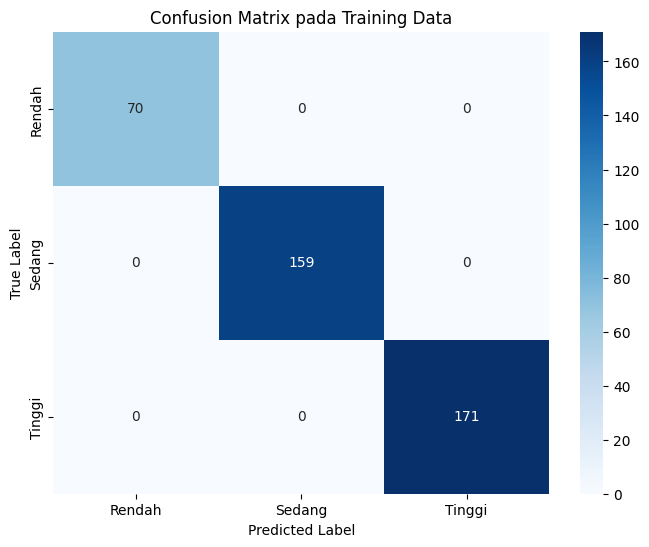


Akurasi Model pada Testing Data: 0.92

Classification Report pada Testing Data:
              precision    recall  f1-score   support

      Rendah       0.93      0.81      0.87        16
      Sedang       0.90      0.93      0.91        40
      Tinggi       0.93      0.95      0.94        44

    accuracy                           0.92       100
   macro avg       0.92      0.90      0.91       100
weighted avg       0.92      0.92      0.92       100



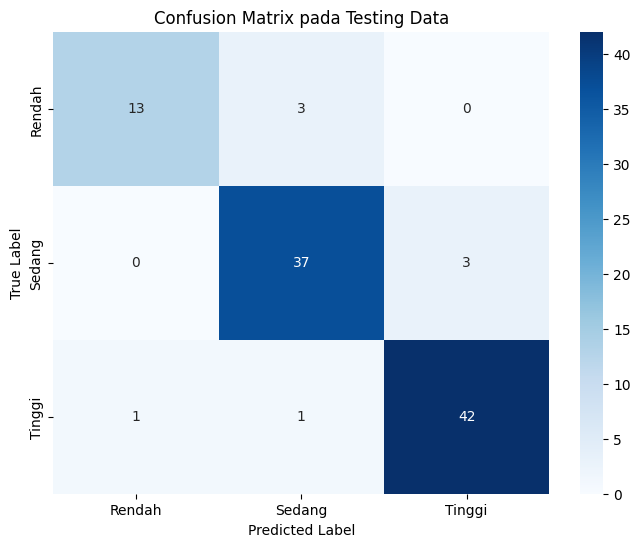

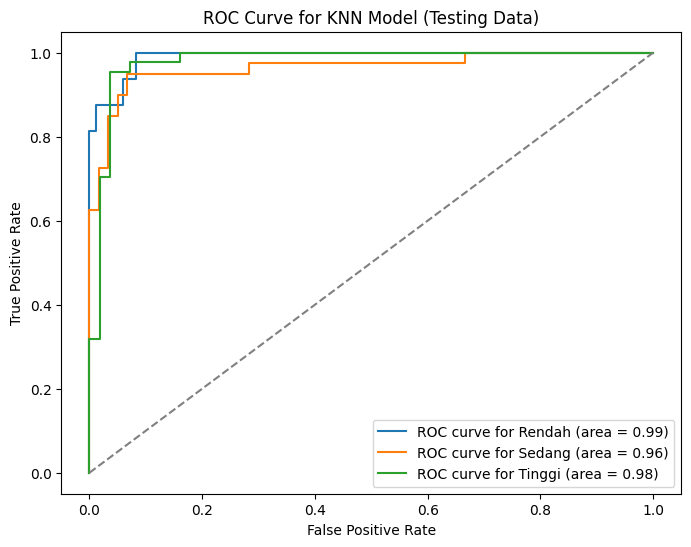

In [ ]:
# GridSearchCV untuk mencari parameter terbaik
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Hasil GridSearchCV
best_params = grid_search.best_params_
print(f"Best parameters from GridSearchCV: {best_params}")

# Gunakan parameter terbaik untuk retrain model
best_knn = grid_search.best_estimator_

# ===================================
# Evaluasi kinerja model pada TRAINING DATA
# ===================================
y_train_pred = best_knn.predict(X_train)

# Evaluasi Training
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"\nAkurasi Model pada Training Data: {train_accuracy:.2f}")

# Classification Report Training
print("\nClassification Report pada Training Data:")
try:
    print(classification_report(y_train, y_train_pred, target_names=label_encoder.classes_))
except:
    print("Pastikan label_encoder sudah didefinisikan dengan benar.")

# Confusion Matrix Training
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix pada Training Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ===================================
# Evaluasi kinerja model pada TESTING DATA
# ===================================
y_test_pred = best_knn.predict(X_test)

# Evaluasi Testing
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\nAkurasi Model pada Testing Data: {test_accuracy:.2f}")

# Classification Report Testing
print("\nClassification Report pada Testing Data:")
try:
    print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
except:
    print("Pastikan label_encoder sudah didefinisikan dengan benar.")

# Confusion Matrix Testing
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix pada Testing Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ===================================
# Analisis ROC Curve untuk TESTING DATA
# ===================================
y_test_bin = label_binarize(y_test, classes=range(len(label_encoder.classes_)))
y_pred_prob = best_knn.predict_proba(X_test)

# Hitung ROC dan AUC untuk setiap kelas
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(8, 6))
for i in range(len(label_encoder.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve for {label_encoder.classes_[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve for KNN Model (Testing Data)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Data testing
# Format: [Umur, Jumlah_Trombosit, Suhu_Tubuh, Ruam_Kulit (0=Tidak, 1=Ya), Nyeri_Otot (0=Tidak, 1=Ya)]
data_testing = [
    [10, 120000, 39.0, 1, 1],
]

data_testing = pd.DataFrame(data_testing, columns=['Umur', 'Jumlah_Trombosit', 'Suhu_Tubuh', 'Ruam_Kulit', 'Nyeri_Otot'])
print("\nData Testing Baru: ")
print(data_testing)


Data Testing Baru: 
   Umur  Jumlah_Trombosit  Suhu_Tubuh  Ruam_Kulit  Nyeri_Otot
0    10            120000        39.0           1           1


In [ ]:
from scipy.spatial.distance import cityblock
# Standarisasi data testing
data_testing_scaled = scaler.transform(data_testing)

# Hitung jarak Manhattan (Cityblock) antara data testing dan seluruh data latih
jarak_manhattan = [cityblock(data_testing_scaled[0], data_latih) for data_latih in X_train]

# Buat dataframe untuk menampilkan jarak dan label
hasil_jarak = pd.DataFrame({
    'Jarak': jarak_manhattan,
    'Label': y_train  # Label data latih
})

# Urutkan berdasarkan jarak terkecil
hasil_jarak = hasil_jarak.sort_values(by='Jarak')
print("\nJarak Manhattan ke Seluruh Data Latih:")
print(hasil_jarak)


Jarak Manhattan ke Seluruh Data Latih:
         Jarak  Label
4     0.088332      2
436   0.596704      2
342   0.767776      2
314   0.835338      2
237   0.956601      2
..         ...    ...
295  10.697166      0
26   10.752004      1
126  11.007468      1
241  11.555301      0
195  11.753336      0

[400 rows x 2 columns]


In [ ]:
# Ambil k tetangga terdekat
k = 9  # Tentukan nilai k
k_tetangga_terdekat = hasil_jarak.head(k)
print(f"\n{k} Tetangga Terdekat:")
print(k_tetangga_terdekat)

# Tentukan kelas berdasarkan mayoritas label di k tetangga terdekat
prediksi_label = k_tetangga_terdekat['Label'].mode()[0]
print(f"\nPrediksi Label untuk Data Testing: {prediksi_label}")

# Menambahkan prediksi label ke data testing untuk referensi
data_testing['Prediksi_Label'] = prediksi_label

# Menampilkan hasil akhir data testing
data_testing['K_Terdekat'] = k_tetangga_terdekat['Label'].values[:len(data_testing)]
print("\nHasil Akhir Data Testing dengan Prediksi:")
print(data_testing)


9 Tetangga Terdekat:
        Jarak  Label
4    0.088332      2
436  0.596704      2
342  0.767776      2
314  0.835338      2
237  0.956601      2
471  1.020502      2
164  1.100084      2
419  1.141864      1
287  1.199108      2

Prediksi Label untuk Data Testing: 2

Hasil Akhir Data Testing dengan Prediksi:
   Umur  Jumlah_Trombosit  Suhu_Tubuh  Ruam_Kulit  Nyeri_Otot  Prediksi_Label  \
0    10            120000        39.0           1           1               2   

   K_Terdekat  
0           2  


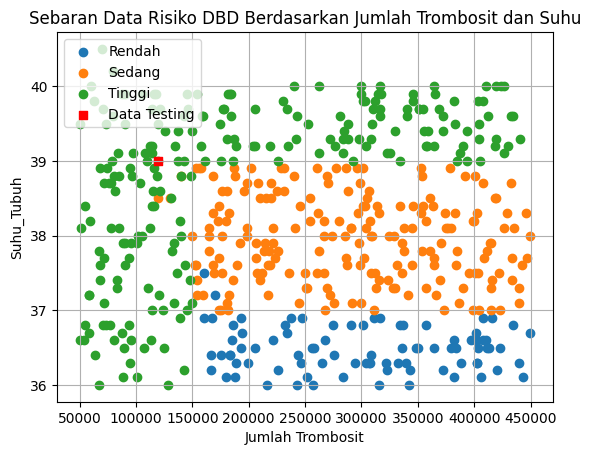

In [ ]:
fig, ax = plt.subplots()
# Tambahkan kolom Risiko_DBD ke dataframe untuk visualisasi
df['Risiko_DBD_Label'] = label_encoder.inverse_transform(df['Risiko_DBD'])

for risiko_dbd, group_data in df.groupby('Risiko_DBD_Label'):
    ax.scatter(group_data['Jumlah_Trombosit'], group_data['Suhu_Tubuh'], label=f"{risiko_dbd}")

# Plot data testing
plt.scatter(data_testing['Jumlah_Trombosit'], data_testing['Suhu_Tubuh'], marker='s', color='red', label='Data Testing')
plt.legend(loc='upper left')
plt.title('Sebaran Data Risiko DBD Berdasarkan Jumlah Trombosit dan Suhu')
plt.xlabel('Jumlah Trombosit')
plt.ylabel('Suhu_Tubuh')
plt.grid(True)
plt.show()